In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Creating the dataframe
df  = pd.read_csv('german_credit_data.csv')
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [3]:
df.shape

(1000, 11)

In [4]:
df.sample(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
89,89,28,male,2,own,little,little,1108,12,repairs,bad
648,648,38,male,2,free,little,rich,947,24,car,bad
893,893,34,male,2,own,little,moderate,5800,36,car,good
479,479,44,male,2,own,little,little,1478,15,furniture/equipment,good
608,608,33,male,2,own,little,NaN,2051,18,radio/TV,good


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [7]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
# One-hot encoding for multicategorical data
# Binary encoding for two catgory
# Label encoding for the labels
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [12]:
# As the savings account and checking account has huge impact 
# We cant fill them 
df.drop(columns = 'Unnamed: 0', inplace=True)

In [13]:
df.sample(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
990,37,male,1,own,NaN,NaN,3565,12,education,good
701,46,male,2,free,little,little,6331,48,car,bad
353,28,male,2,rent,little,little,6199,12,radio/TV,bad
51,30,male,3,own,little,moderate,5965,27,car,good
655,22,male,2,free,little,little,3973,14,car,good


In [14]:
df = df.dropna().reset_index(drop=True)

In [16]:
df.shape

(522, 10)

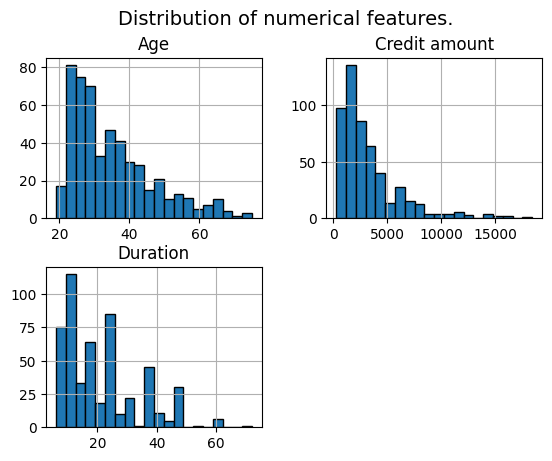

In [17]:
# Plot the age, credit amount, duration
df[["Age", "Credit amount", "Duration"]].hist(bins=20, edgecolor='black')
plt.suptitle("Distribution of numerical features.", fontsize=14)
plt.show()

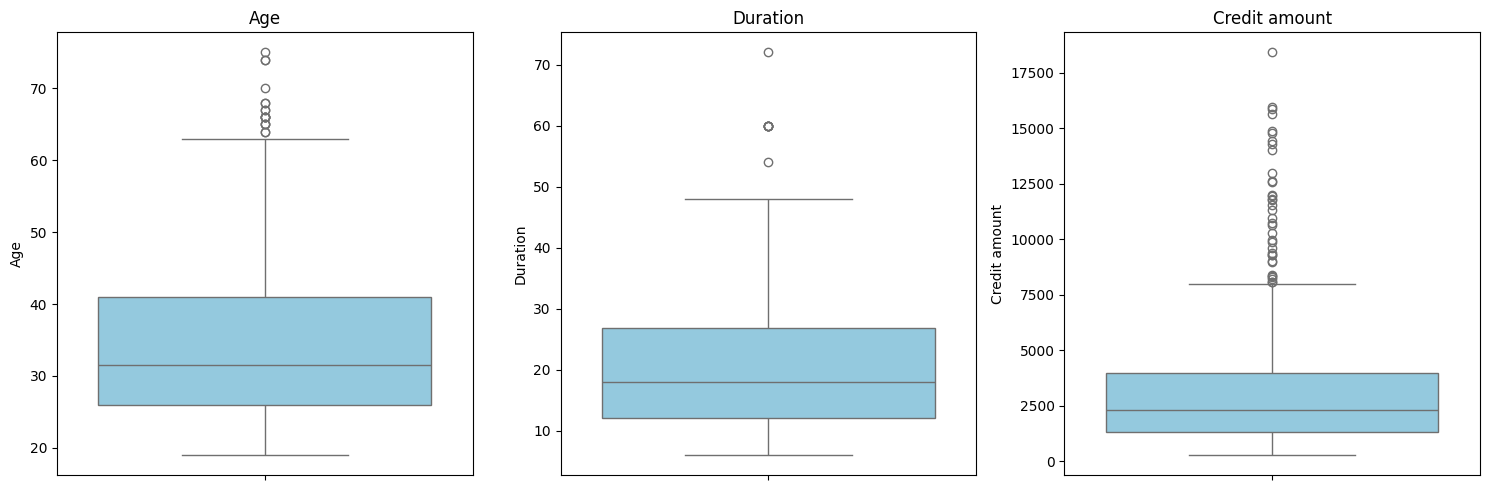

In [21]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(["Age", "Duration", "Credit amount"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [22]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [26]:
# Filtering the categorical columns
categorical_cols = ["Sex", "Job", "Housing", "Purpose", "Saving accounts", "Checking account"]

/tmp/ipykernel_86178/442636752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette= "Set2", order=df[col].value_counts().index)
/tmp/ipykernel_86178/442636752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette= "Set2", order=df[col].value_counts().index)
/tmp/ipykernel_86178/442636752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette= "Set2", order=df[col].value_counts().index)
/tmp/ipykernel_86178/442636752.py:4: FutureWarning: 

Passing `palette` without assig

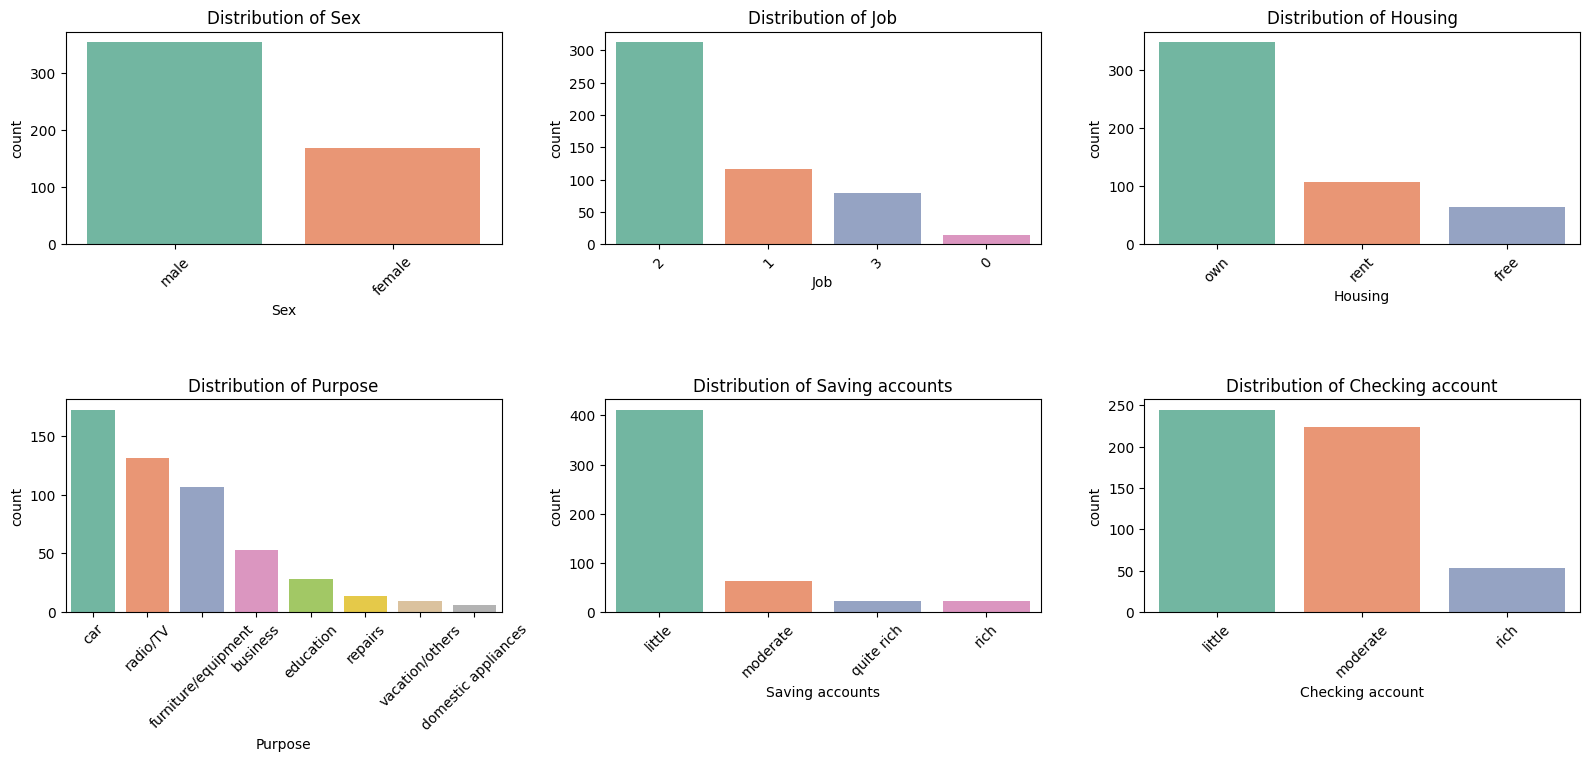

In [31]:
plt.figure(figsize=(16,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, palette= "Set2", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

In [32]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [33]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


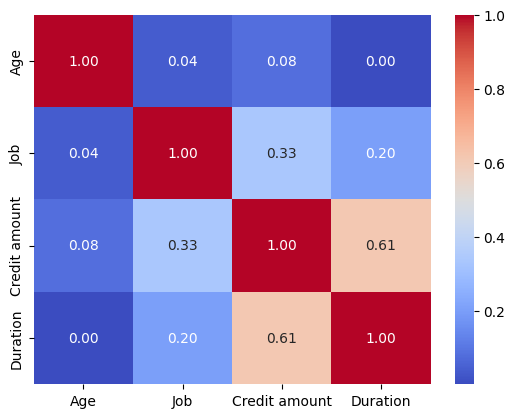

In [34]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [35]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [36]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [38]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


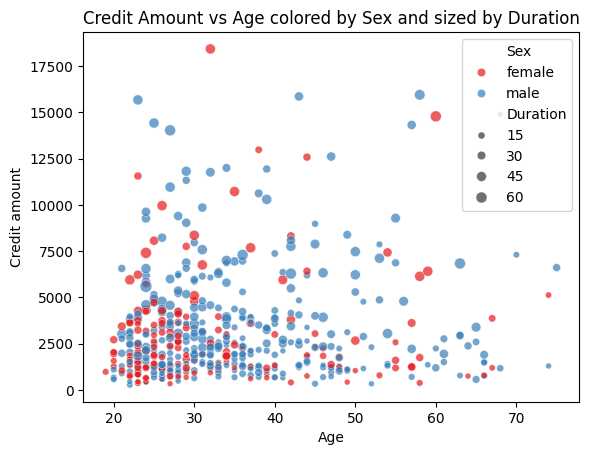

In [40]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit Amount vs Age colored by Sex and sized by Duration")
plt.show()

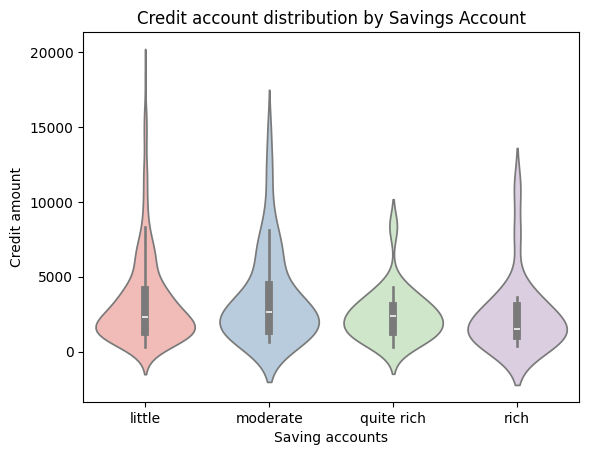

In [44]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1", hue="Saving accounts", legend=False)
plt.title("Credit account distribution by Savings Account")
plt.show()

In [45]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

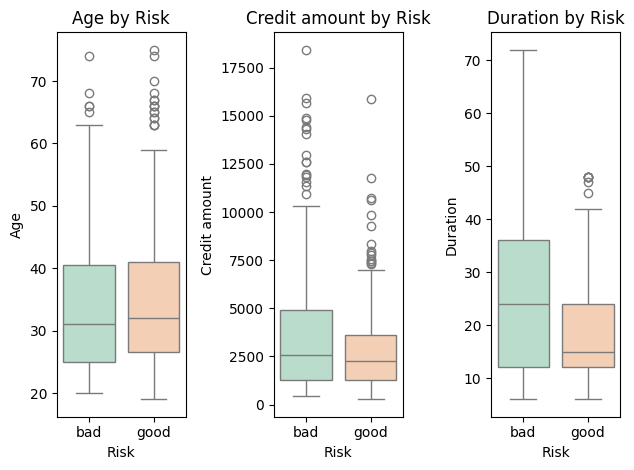

In [48]:
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2", hue="Risk", legend=False)
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [49]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


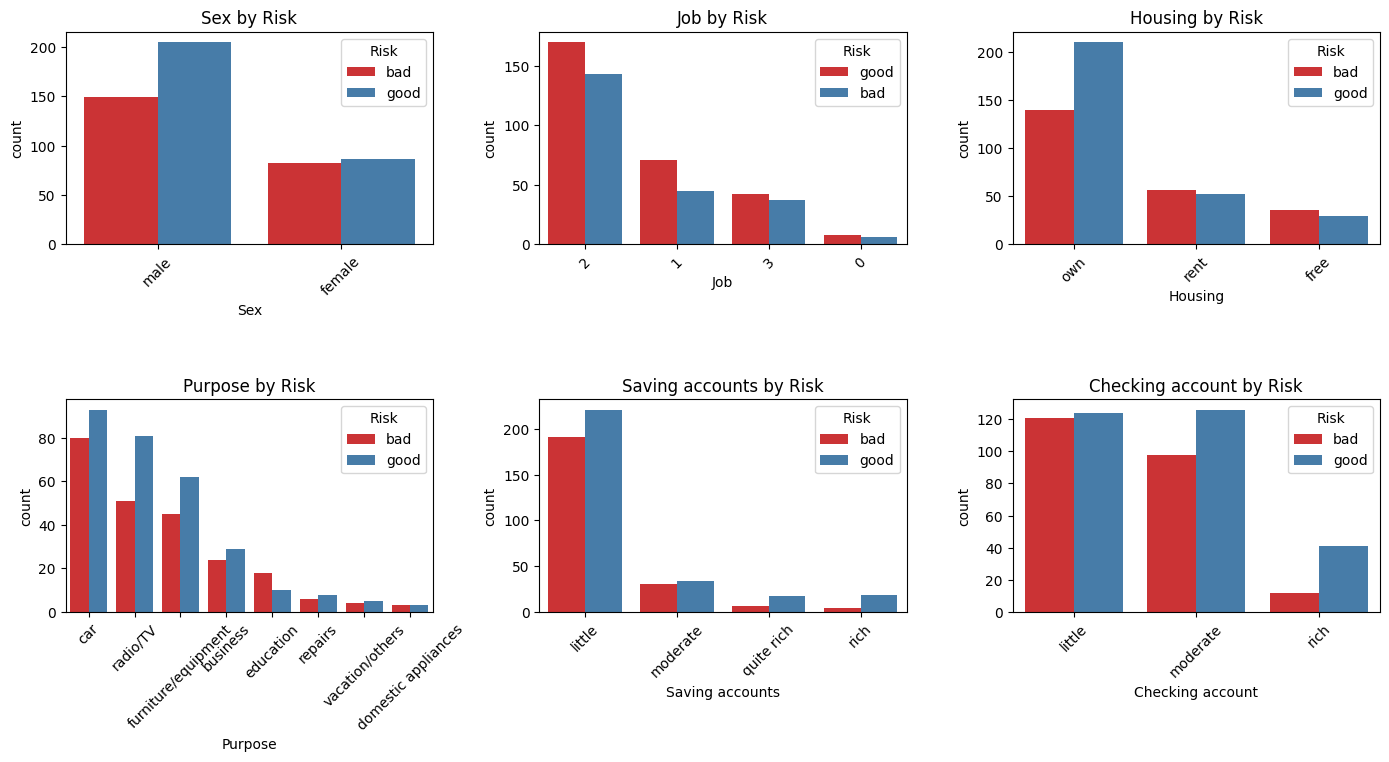

In [58]:
# Again we will plot the count plot for all the categorical data 
plt.figure(figsize=(13,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [59]:
# Feature engineering started 
df2 = df.drop(columns="Purpose", axis=1)

In [60]:
df2.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Risk'],
      dtype='object')

In [72]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [68]:
cat_cols = df2.select_dtypes(include="object").columns.drop("Risk")

In [73]:
le_dict = {}

In [74]:
for col in cat_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [75]:
le_target = LabelEncoder()
df2["Risk"] = le_target.fit_transform(df2["Risk"])

In [76]:
df2["Risk"]

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [77]:
joblib.dump(le_target, "Risk_encoder.pkl")

['Risk_encoder.pkl']

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
X = df2.drop(columns="Risk")
y = df2["Risk"]

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [82]:
X_train.shape

(417, 8)

In [83]:
X_test.shape

(105, 8)

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [88]:
# Function to train the model 
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [89]:
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [94]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [95]:
print("Decision Tree accuracy:- ", acc_dt)

Decision Tree accuracy:-  0.6


In [96]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [97]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

In [99]:
rf_params_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [100]:
best_rf , acc_rf, best_params_rf = train_model(rf, rf_params_grid, X_train, y_train, X_test, y_test)

/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit

In [101]:
print("Randome Forest accuracy:- ", acc_rf)

Randome Forest accuracy:-  0.6285714285714286


In [103]:
print("Best parameters of random forest:- ", best_params_rf)

Best parameters of random forest:-  {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [111]:
et = ExtraTreesClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
et_params_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [112]:
best_et, acc_et, best_params_et = train_model(et, et_params_grid, X_train, y_train, X_test, y_test)

/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit

In [113]:
print("Extra trees classifier accuracy:- ", acc_et)

Extra trees classifier accuracy:-  0.6285714285714286


In [114]:
print("Extra trees best parameters:- ", best_params_et)

Extra trees best parameters:-  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [115]:
 xgb = XGBClassifier(random_state=1, scale_pos_weight=(y_train == 0).sum()/ (y_train == 1).sum(), use_label_encoder=False, eval_metric="logloss")

In [116]:
xgb_params_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}

In [124]:
best_xgb, acc_xgb, best_params_xgb = train_model(xgb, xgb_params_grid, X_train, y_train, X_test, y_test)

/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:02:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:02:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:02:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/codebind/Documents/pet_projects/Kidney-disease-Classification-/.venv/lib/python3.12/site-packages

In [125]:
print("XGBoost accuracy:- ", acc_xgb)

XGBoost accuracy:-  0.6952380952380952


In [126]:
print("XGBoost best params:- ", best_params_xgb)

XGBoost best params:-  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


In [127]:
joblib.dump(best_xgb, "xgb_credit_model.pkl")

['xgb_credit_model.pkl']

In [128]:
joblib.dump(best_rf, "random_forest_credit_model.pkl")
joblib.dump(best_dt, "decision_tree_credit_model.pkl")
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']